In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

In [2]:
conn = sqlite3.connect("news.db")


In [3]:
# compare average length of fake and real news articles
length_df = pd.read_sql_query("SELECT l.label, AVG(LENGTH(a.text)) AS avg_length, MIN(LENGTH(a.text)) AS min_length, MAX(LENGTH(a.text)) AS max_length FROM Articles a JOIN Labels l ON a.article_id = l.article_id GROUP BY l.label", conn)
length_df
# min length of 1 indicates possibly bad rows that need to be taken care of during cleaning/preprocessing
# fake news articles tend to be longer (using full dataset) than real news articles, possibly in order to boost credibility by using more words?

,label,avg_length,min_length,max_length
0,fake,2305.72,1579,4039
1,real,2520.82,402,6754


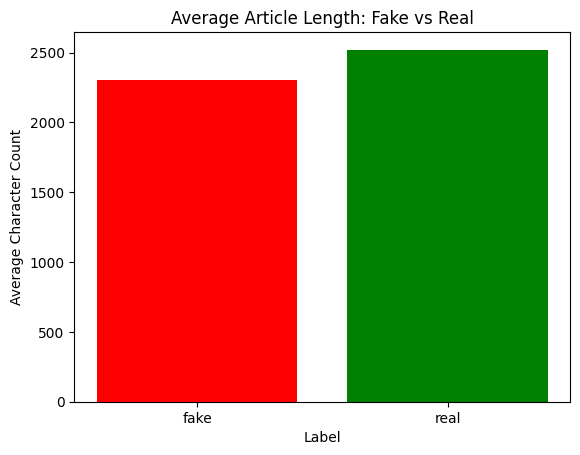

In [4]:
plt.bar(length_df["label"], length_df["avg_length"], color=["red", "green"])
plt.title("Average Article Length: Fake vs Real")
plt.xlabel("Label")
plt.ylabel("Average Character Count")
plt.show()

In [5]:
# check out subject distribution for fake and real news
subject_df = pd.read_sql_query("SELECT a.subject, l.label, COUNT(*) AS article_count FROM Articles a JOIN Labels l ON a.article_id = l.article_id GROUP BY a.subject, l.label ORDER BY article_count DESC", conn)
subject_df
# results are a little strange as subject names are not shared between real and fake news records
# subject might have been a feature added by the person who made the dataset rather than the article itself, so I'm a little 
# suspicious of relying on subject as a parameter for the model (might classify based on that alone rather than the actual
# content of the article and can overfit the model)

,subject,label,article_count
0,News,fake,50
1,politicsNews,real,50


In [ ]:
# maybe there are clusters around certain dates?
date_df = pd.read_sql_query("SELECT a.date, l.label, COUNT(*) AS article_count FROM Articles a JOIN Labels l ON a.article_id = l.article_id GROUP BY a.date, l.label ORDER BY a.date", conn)
date_df["date"] = pd.to_datetime(date_df["date"], errors="coerce")
print(date_df.head(10))
print(date_df.tail(10))
# datasets run from arund 2015-2018
# some NaT rows at bottom (maybe other places as well) which might need to be dropped after closer inspection
date_df = date_df.dropna()
fake_dates = date_df[date_df["label"] == "fake"]
real_dates = date_df[date_df["label"] == "real"]

plt.figure(figsize=(12, 5))
plt.plot(fake_dates["date"], fake_dates["article_count"], color="red", label="Fake", alpha=0.7)
plt.plot(real_dates["date"], real_dates["article_count"], color="green", label="Real", alpha=0.7)
plt.title("Article Distribution Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.legend()
plt.tight_layout()
plt.show()
# terrible graph, too many points make it incomprehensible -- going to have to aggregate the data, probably by month

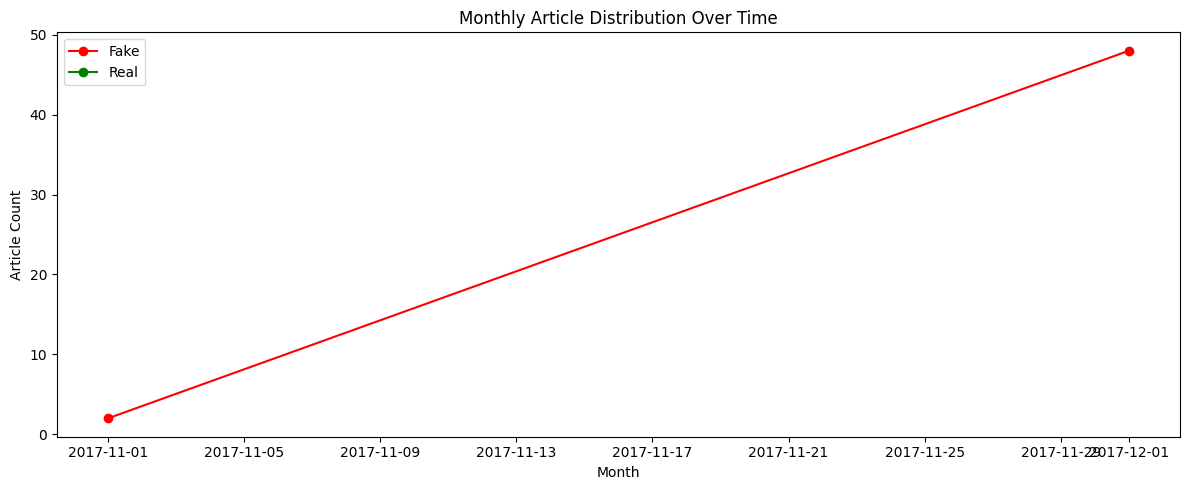

In [7]:
date_df["month"] = date_df["date"].dt.to_period("M")

monthly_labels = date_df.groupby(["month", "label"])["article_count"].sum().reset_index()
monthly_labels["month"] = monthly_labels["month"].dt.to_timestamp()

fake_monthly_labels = monthly_labels[monthly_labels["label"] == "fake"]
real_monthly_labels = monthly_labels[monthly_labels["label"] == "real"]

plt.figure(figsize=(12, 5))
plt.plot(fake_monthly_labels["month"], fake_monthly_labels["article_count"], color="red", label="Fake", marker="o")
plt.plot(real_monthly_labels["month"], real_monthly_labels["article_count"], color="green", label="Real", marker="o")
plt.title("Monthly Article Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Article Count")
plt.legend()
plt.tight_layout()
plt.show()
# fake news has much bigger spread of dates (2015-2018) compared to real news (only 2016-2018)
# real news has a spike in articles in Sep 2017 - Jan 2018
# dates aren't consistent between fake and real news observations, making me question if its a reliable parameter
# I'm starting to think the brunt of training will be on the article content itself rather than metadata

In [8]:
# analyzing word frequencies
# filtering out common words like "the", "a", etc. whose frequencies have no significant meaning
stop_words = set(stopwords.words("english"))
def get_top_words(text_string, n=20):
    all_text = " ".join(text_string).lower()
    words = re.findall(r'\b[a-z]+\b', all_text) # removes punctuation and numbers
    filtered = [w for w in words if w not in stop_words and len(w) > 2] # filters out short words and stopwords
    return Counter(filtered).most_common(n)
raw_text = pd.read_sql_query("SELECT a.title, a.text, l.label FROM Articles a JOIN Labels l ON a.article_id = l.article_id", conn)

fake_words = get_top_words(raw_text[raw_text["label"] == "fake"]["text"])
real_words = get_top_words(raw_text[raw_text["label"] == "real"]["text"])

print("Top 20 words in FAKE articles:")
print(fake_words)
print("\nTop 20 words in REAL articles:")
print(real_words)
# from this alone, I can see that the fake news articles tend to focus on specific political figures, stating their name a lot
# this can indicate how fake news articles tend to serve as political propaganda (presence of twitter AKA social media probably
# being used as a source for these fake news articles)

# Reuters is frequent in real news articles, and it is the name of a very reliable news & media organization that is widely 
# used as a primary source in other news outlets (indicating credibility through citing of trusted sources)

# real news also tends to use less personal diction like "president" rather than name dropping "trump" or "obama"

# diction and vocabulary just seems more formal in the real news articles than fake

Top 20 words in FAKE articles:
[('trump', 286), ('december', 116), ('donald', 76), ('president', 62), ('people', 59), ('twitter', 54), ('fbi', 53), ('said', 49), ('moore', 48), ('flynn', 46), ('one', 45), ('images', 44), ('getty', 43), ('like', 42), ('former', 40), ('even', 39), ('house', 38), ('com', 36), ('year', 35), ('would', 35)]

Top 20 words in REAL articles:
[('said', 228), ('trump', 214), ('president', 85), ('would', 71), ('house', 68), ('new', 68), ('tax', 65), ('reuters', 60), ('year', 59), ('republican', 56), ('also', 56), ('court', 55), ('administration', 52), ('states', 52), ('bill', 49), ('washington', 47), ('democrats', 44), ('republicans', 43), ('federal', 43), ('donald', 42)]


In [9]:
fake_title_words = get_top_words(raw_text[raw_text["label"] == "fake"]["title"])
real_title_words = get_top_words(raw_text[raw_text["label"] == "real"]["title"])

print("Top 20 words in FAKE titles:")
print(fake_title_words)
print("\nTop 20 words in REAL titles:")
print(real_title_words)
# "anti" - negative sentiment? propaganda?
# "video", "watch", "breaking" - clickbaitey titles

Top 20 words in FAKE titles:
[('trump', 33), ('watch', 7), ('video', 7), ('donald', 5), ('fbi', 5), ('senate', 5), ('alabama', 4), ('flynn', 4), ('new', 3), ('comey', 3), ('tweet', 3), ('gop', 3), ('losing', 3), ('mueller', 3), ('roy', 3), ('moore', 3), ('senator', 3), ('gets', 3), ('democrat', 3), ('white', 3)]

Top 20 words in REAL titles:
[('trump', 23), ('tax', 9), ('twitter', 7), ('dec', 7), ('house', 6), ('bill', 6), ('court', 5), ('congress', 4), ('spending', 4), ('senate', 4), ('military', 3), ('transgender', 3), ('recruits', 3), ('probe', 3), ('factbox', 3), ('jones', 3), ('challenge', 3), ('new', 3), ('law', 3), ('election', 3)]


In [10]:
conn.close()